In [112]:
import pandas as pd

path="2014_alaya_september/laya_140909.s4"
# Carpeta donde están tus archivos
ruta = "2014_alaya_september/*.s4"
# Nombre del archivo con dataset god
nombre_archivo_csv="Ayacucho_S4_Sep2014"

rows = []
with open(path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 5:  # mínimo para incluir esa columna extra
            continue

        year = int(parts[0])
        doy = int(parts[1])
        seconds = int(parts[2])
        ch_id = int(parts[3])   # <--- esta es la misteriosa columna 4

        sat_data = parts[4:]  # <--- los datos reales comienzan aquí
        for i in range(0, len(sat_data), 4):
            try:
                prn = int(sat_data[i])
                s4 = float(sat_data[i+1])
                az = float(sat_data[i+2])
                el = float(sat_data[i+3])
                rows.append([year, doy, seconds, ch_id, prn, s4, az, el])
            except:
                pass

df = pd.DataFrame(rows, columns=["YEAR", "DOY", "SECONDS", "CH_ID", "PRN", "S4", "Az", "El"])
print(df.head())


   YEAR  DOY  SECONDS  CH_ID  PRN    S4     Az    El
0    14  252    45658     12    1  0.05  164.6  60.0
1    14  252    45658     12    4  0.05  201.7  39.6
2    14  252    45658     12   11  0.04   92.6  81.3
3    14  252    45658     12   13  0.05  312.9  46.4
4    14  252    45658     12   17  0.23  226.9  15.5


In [90]:
print(df.dtypes)

YEAR         int64
DOY          int64
SECONDS      int64
CH_ID        int64
PRN          int64
S4         float64
Az         float64
El         float64
dtype: object


In [91]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38594 entries, 0 to 38593
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     38594 non-null  int64  
 1   DOY      38594 non-null  int64  
 2   SECONDS  38594 non-null  int64  
 3   CH_ID    38594 non-null  int64  
 4   PRN      38594 non-null  int64  
 5   S4       38594 non-null  float64
 6   Az       38594 non-null  float64
 7   El       38594 non-null  float64
dtypes: float64(3), int64(5)
memory usage: 2.4 MB
None


In [92]:
print(df.isna().sum())

YEAR       0
DOY        0
SECONDS    0
CH_ID      0
PRN        0
S4         0
Az         0
El         0
dtype: int64


In [93]:
# Irrelevantesxd
print(df.describe()[["YEAR", "DOY", "SECONDS", "CH_ID"]])

          YEAR      DOY       SECONDS         CH_ID
count  38594.0  38594.0  38594.000000  38594.000000
mean      24.0    336.0  42950.263253     27.172203
std        0.0      0.0  24860.471243      1.552621
min       24.0    336.0     60.000000     23.000000
25%       24.0    336.0  21120.000000     26.000000
50%       24.0    336.0  43500.000000     27.000000
75%       24.0    336.0  64500.000000     28.000000
max       24.0    336.0  85500.000000     32.000000


In [94]:
#:o, el PRN ta de coladoxd
print(df.describe()[["PRN","S4", "Az", "El"]])

                PRN            S4            Az            El
count  38594.000000  38594.000000  38594.000000  38594.000000
mean      64.851117      0.073230    189.478339     36.515521
std       47.660753      0.066152    104.268679     17.477578
min        2.000000      0.000000      0.000000      6.000000
25%       25.000000      0.030000     99.000000     23.000000
50%       55.000000      0.058000    201.000000     34.000000
75%       95.000000      0.099000    280.000000     47.000000
max      205.000000      0.964000    359.000000     90.000000


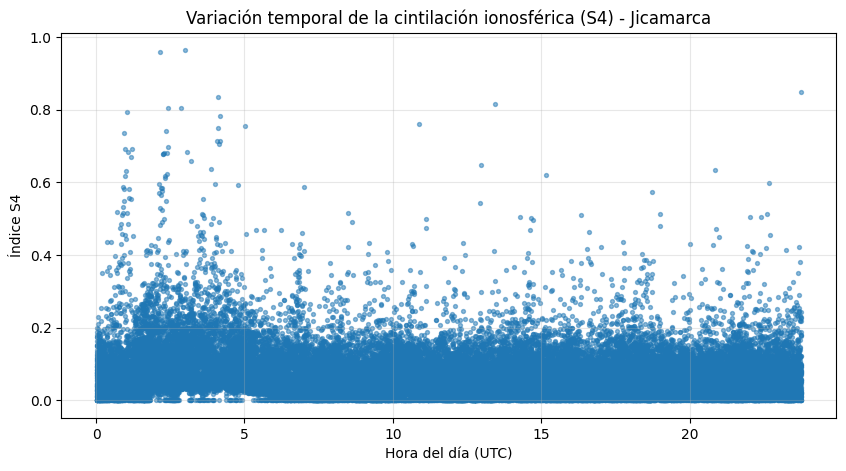

In [95]:
#Te mostrará en qué horas del día aparecen los picos de S4

import matplotlib.pyplot as plt

df["HOUR_DEC"] = df["SECONDS"] / 3600  # segundos del día → horas decimales

plt.figure(figsize=(10,5))
plt.scatter(df["HOUR_DEC"], df["S4"], s=8, alpha=0.5)
plt.xlabel("Hora del día (UTC)")
plt.ylabel("Índice S4")
plt.title("Variación temporal de la cintilación ionosférica (S4) - Jicamarca")
plt.grid(alpha=0.3)
plt.show()


##### Para ver en qué dirección del cielo aparecen las cintilaciones (Azimut–Elevación)

Esto genera un mapa de dispersión Az–El coloreado por intensidad S4.
Si ves S4 altos (rojos) a bajas elevaciones (~20–30°), es consistente con el comportamiento esperado en la región ecuatorial.

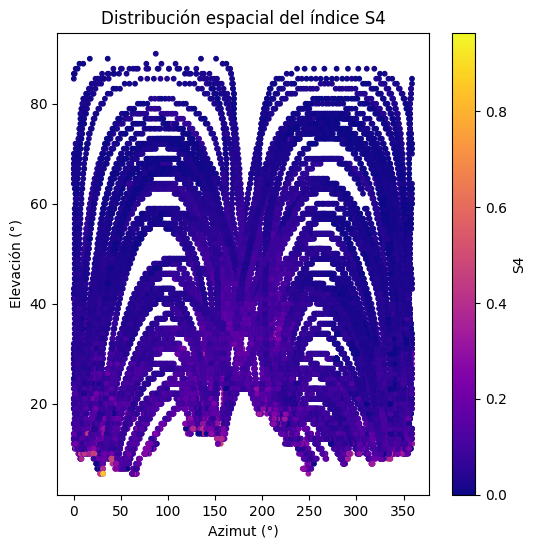

In [96]:
plt.figure(figsize=(6,6))
plt.scatter(df["Az"], df["El"], c=df["S4"], cmap="plasma", s=10)
plt.colorbar(label="S4")
plt.xlabel("Azimut (°)")
plt.ylabel("Elevación (°)")
plt.title("Distribución espacial del índice S4")
plt.show()

In [97]:
# S4 promedio por PRN
print(df.groupby("PRN")["S4"].mean().sort_values(ascending=False).head(10))


PRN
85     0.258083
78     0.165847
100    0.152182
48     0.124310
47     0.121077
38     0.114800
61     0.114501
45     0.113446
42     0.111320
49     0.107737
Name: S4, dtype: float64


In [98]:
# S4 promedio por canal
print(df.groupby("CH_ID")["S4"].mean().sort_values(ascending=False))

CH_ID
29    0.080670
30    0.078742
27    0.073622
28    0.073392
31    0.071835
32    0.071109
23    0.070217
26    0.069519
25    0.068785
24    0.063154
Name: S4, dtype: float64


In [99]:
import pandas as pd
import datetime as dt

# Aseguramos los tipos
df["YEAR"] = df["YEAR"].astype(int)
df["DOY"] = df["DOY"].astype(int)
df["SECONDS"] = df["SECONDS"].astype(int)

# Calculamos el año completo (ej: 2023)
df["YEAR_FULL"] = 2000 + df["YEAR"]

# Convertimos DOY y SECONDS a fecha completa usando vectorización
df["DATETIME"] = pd.to_datetime(df["YEAR_FULL"].astype(str), format="%Y") + \
                 pd.to_timedelta(df["DOY"] - 1, unit="D") + \
                 pd.to_timedelta(df["SECONDS"], unit="s")

# Verificamos
print(df[["YEAR_FULL", "DOY", "SECONDS", "DATETIME"]].head())


   YEAR_FULL  DOY  SECONDS            DATETIME
0       2024  336       60 2024-12-01 00:01:00
1       2024  336       60 2024-12-01 00:01:00
2       2024  336       60 2024-12-01 00:01:00
3       2024  336       60 2024-12-01 00:01:00
4       2024  336       60 2024-12-01 00:01:00


In [100]:
df["HOUR"] = df["DATETIME"].dt.hour

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38594 entries, 0 to 38593
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   YEAR       38594 non-null  int32         
 1   DOY        38594 non-null  int32         
 2   SECONDS    38594 non-null  int32         
 3   CH_ID      38594 non-null  int64         
 4   PRN        38594 non-null  int64         
 5   S4         38594 non-null  float64       
 6   Az         38594 non-null  float64       
 7   El         38594 non-null  float64       
 8   HOUR_DEC   38594 non-null  float64       
 9   YEAR_FULL  38594 non-null  int32         
 10  DATETIME   38594 non-null  datetime64[ns]
 11  HOUR       38594 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(5), int64(2)
memory usage: 2.8 MB


<Axes: xlabel='HOUR', ylabel='S4'>

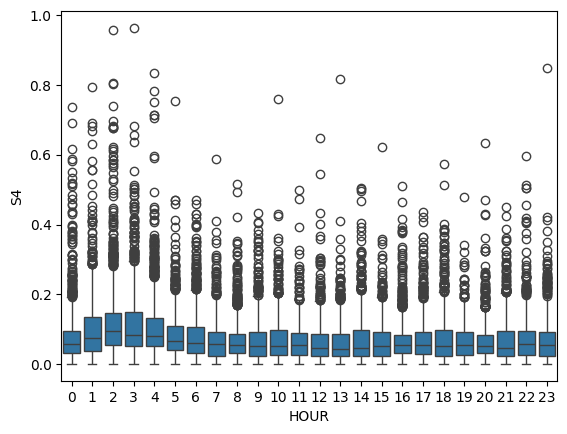

In [102]:
import seaborn as sns
sns.boxplot(x="HOUR", y="S4", data=df)

In [103]:
import pandas as pd
import glob
import datetime as dt

# Lista de archivos .s4
archivos = sorted(glob.glob(ruta))
print(f"Encontrados {len(archivos)} archivos.")

def leer_s4(path):
    """Lee un archivo .s4 individual y devuelve un DataFrame."""
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            year = int(parts[0])
            doy = int(parts[1])
            seconds = int(parts[2])
            ch_id = int(parts[3])
            sat_data = parts[4:]

            for i in range(0, len(sat_data), 4):
                try:
                    prn = int(sat_data[i])
                    s4 = float(sat_data[i+1])
                    az = float(sat_data[i+2])
                    el = float(sat_data[i+3])
                    rows.append([year, doy, seconds, ch_id, prn, s4, az, el])
                except:
                    pass

    df = pd.DataFrame(rows, columns=["YEAR", "DOY", "SECONDS", "CH_ID", "PRN", "S4", "Az", "El"])
    df["YEAR_FULL"] = 2000 + df["YEAR"]
    df["DATETIME"] = pd.to_datetime(df["YEAR_FULL"].astype(str), format="%Y") + \
                     pd.to_timedelta(df["DOY"] - 1, unit="D") + \
                     pd.to_timedelta(df["SECONDS"], unit="s")
    return df

# Leer y unir todos los archivos
df_all = pd.concat([leer_s4(f) for f in archivos], ignore_index=True)

print("✅ Dataset combinado listo.")
print(df_all[["DATETIME", "PRN", "S4", "Az", "El"]].head())
print(f"Total de filas: {len(df_all):,}")


Encontrados 31 archivos.
✅ Dataset combinado listo.
             DATETIME  PRN     S4     Az    El
0 2024-12-01 00:01:00    2  0.179   26.0  19.0
1 2024-12-01 00:01:00    3  0.061  104.0  33.0
2 2024-12-01 00:01:00    4  0.152  153.0  24.0
3 2024-12-01 00:01:00    6  0.095  221.0  40.0
4 2024-12-01 00:01:00    7  0.000    7.0  78.0
Total de filas: 1,156,137


In [104]:
df_all.to_csv(nombre_archivo_csv+".csv", index=False)

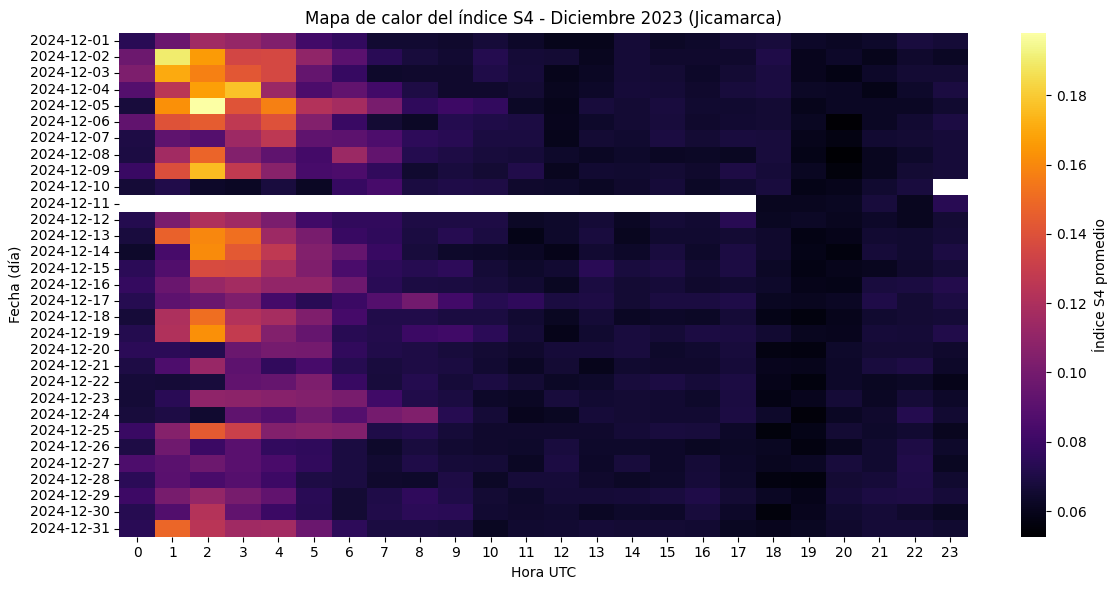

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurarnos de que df_all tenga la columna DATETIME
df_all["fecha"] = df_all["DATETIME"].dt.date
df_all["hora"] = df_all["DATETIME"].dt.hour

# Calculamos el promedio de S4 por día y hora
pivot = df_all.pivot_table(values="S4", index="fecha", columns="hora", aggfunc="mean")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="inferno", cbar_kws={"label": "Índice S4 promedio"})
plt.title("Mapa de calor del índice S4 - Diciembre 2023 (Jicamarca)")
plt.xlabel("Hora UTC")
plt.ylabel("Fecha (día)")
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_25512\3059765782.py:9: FutureWarning: The provided callable <function mean at 0x00000115FBB1CFE0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_eventos = df_all.pivot_table(values="evento", index="fecha", columns="hora", aggfunc=np.mean)


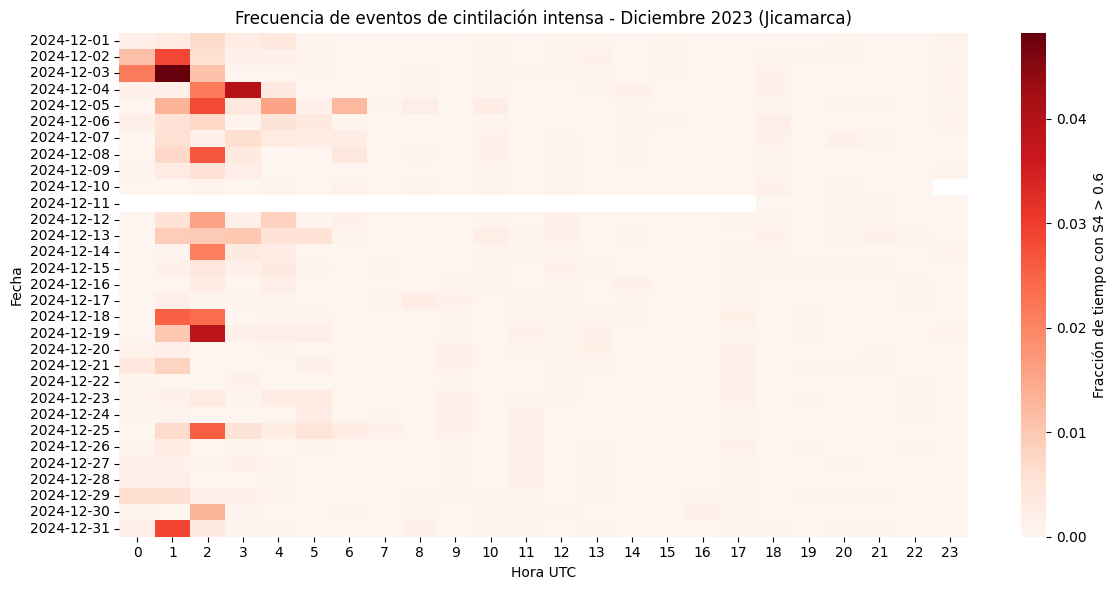

In [106]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos umbral de evento crítico (ej. S4 > 0.6)
df_all["evento"] = df_all["S4"] > 0.6

# Contamos proporción de tiempo con cintilación fuerte
pivot_eventos = df_all.pivot_table(values="evento", index="fecha", columns="hora", aggfunc=np.mean)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_eventos, cmap="Reds", cbar_kws={"label": "Fracción de tiempo con S4 > 0.6"})
plt.title("Frecuencia de eventos de cintilación intensa - Diciembre 2023 (Jicamarca)")
plt.xlabel("Hora UTC")
plt.ylabel("Fecha")
plt.tight_layout()
plt.show()


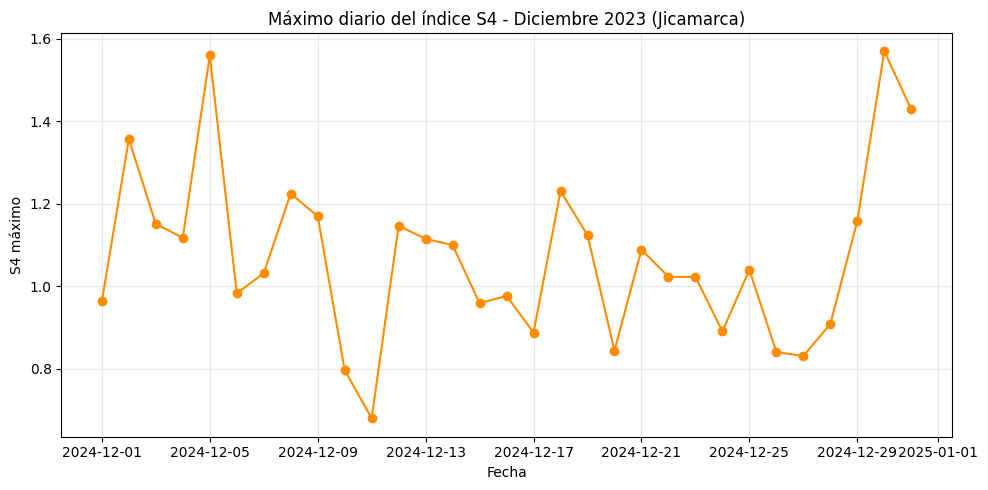

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

# Agrupar por día y obtener el máximo S4
max_s4_diario = df_all.groupby("fecha")["S4"].max()

plt.figure(figsize=(10,5))
plt.plot(max_s4_diario.index, max_s4_diario.values, marker='o', linestyle='-', color='darkorange')
plt.title("Máximo diario del índice S4 - Diciembre 2023 (Jicamarca)")
plt.xlabel("Fecha")
plt.ylabel("S4 máximo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


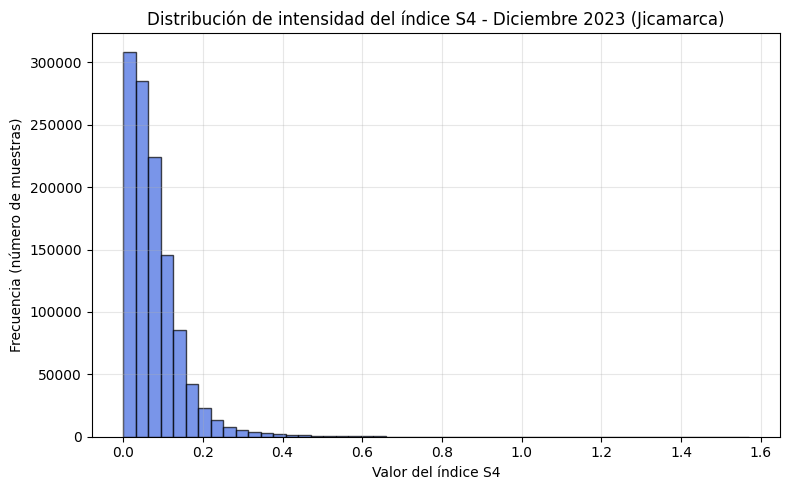

In [108]:
plt.figure(figsize=(8,5))
plt.hist(df_all["S4"], bins=50, color='royalblue', alpha=0.7, edgecolor='black')
plt.title("Distribución de intensidad del índice S4 - Diciembre 2023 (Jicamarca)")
plt.xlabel("Valor del índice S4")
plt.ylabel("Frecuencia (número de muestras)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [109]:
import numpy as np

# Estadísticos generales
mean_s4 = df_all["S4"].mean()
max_s4 = df_all["S4"].max()
p90_s4 = np.percentile(df_all["S4"], 90)
frac_strong = (df_all["S4"] > 0.6).mean() * 100

# Día y hora del pico máximo
fila_max = df_all.loc[df_all["S4"].idxmax(), ["DATETIME", "S4"]]

print("📊 RESUMEN DICIEMBRE 2023 - JICAMARCA")
print(f"Promedio general S4: {mean_s4:.3f}")
print(f"Pico máximo S4: {max_s4:.2f} (fecha: {fila_max['DATETIME']})")
print(f"Percentil 90 (S4): {p90_s4:.2f}")
print(f"Frecuencia de eventos S4>0.6: {frac_strong:.2f}% del total")


📊 RESUMEN DICIEMBRE 2023 - JICAMARCA
Promedio general S4: 0.076
Pico máximo S4: 1.57 (fecha: 2024-12-30 02:16:00)
Percentil 90 (S4): 0.15
Frecuencia de eventos S4>0.6: 0.13% del total
